<a href="https://colab.research.google.com/github/mrajani-art/calyx-quoting-system/blob/main/Tedpack_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###############################################################################
# TEAPACK LANDED COST ML PLATFORM — GOOGLE COLAB NOTEBOOK
###############################################################################

# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 1: SETUP & INSTALLS
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 1 — Install dependencies & imports**

# Colab already has most of these, but let's be explicit
!pip install -q scikit-learn pandas numpy matplotlib plotly scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import math
import warnings
from datetime import datetime

# scikit-learn components
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✓ All imports loaded successfully")
print(f"  numpy {np.__version__}")
print(f"  pandas {pd.__version__}")
print(f"  sklearn {__import__('sklearn').__version__}")


✓ All imports loaded successfully
  numpy 2.0.2
  pandas 2.2.2
  sklearn 1.6.1


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 2: LOAD & EXPLORE DATA
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 2 — Load data & initial exploration**

# ── Load the training-ready CSV ──────────────────────────────────────────────
# If you uploaded to Colab, it's in /content/
# If you're using Google Drive, mount first and adjust the path
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Tedpack Sythnetic/teapack_training_ready.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Unique bag specs: {df['fl_number'].nunique()}")
print(f"Date range: {df['quote_date'].min()} → {df['quote_date'].max()}")
print(f"Quantity range: {df['quantity'].min():,} → {df['quantity'].max():,}")

# ── Quick look at the two target variables ───────────────────────────────────
# FOB = what Teapack charges (the ML target)
# Landed = FOB + freight + tariff + customs + insurance (the business target)
print("\n── FOB Unit Price (what ML predicts) ──")
print(df['fob_unit_price'].describe().to_string())

print("\n── Landed Unit Cost (what the business cares about) ──")
print(df['landed_unit_cost'].describe().to_string())

# ── Cost decomposition overview ──────────────────────────────────────────────
# This tells us how much of the landed cost is FOB vs external factors
print("\n── Average Cost Stack ──")
avg_fob = df['fob_unit_price'].mean()
avg_freight = df['freight_per_unit'].mean()
avg_tariff = (df['fob_unit_price'] * df['tariff_rate']).mean()
avg_customs = df['customs_per_unit'].mean()
avg_insurance = df['insurance_per_unit'].mean()
avg_landed = df['landed_unit_cost'].mean()

for label, val in [("FOB", avg_fob), ("Freight", avg_freight),
                    ("Tariff", avg_tariff), ("Customs", avg_customs),
                    ("Insurance", avg_insurance), ("LANDED", avg_landed)]:
    pct = val / avg_landed * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:12s}  ${val:.4f}  {pct:5.1f}%  {bar}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: 499 rows × 39 columns
Unique bag specs: 109
Date range: 2024-01-13 → 2026-02-16
Quantity range: 5,000 → 300,000

── FOB Unit Price (what ML predicts) ──
count    499.000000
mean       0.260890
std        0.141261
min        0.083690
25%        0.163420
50%        0.222850
75%        0.307825
max        1.021050

── Landed Unit Cost (what the business cares about) ──
count    499.000000
mean       0.420064
std        0.225438
min        0.131440
25%        0.268240
50%        0.366070
75%        0.508340
max        1.528090

── Average Cost Stack ──
  FOB           $0.2609   62.1%  ███████████████████████████████
  Freight       $0.0711   16.9%  ████████
  Tariff        $0.0762   18.1%  █████████
  Customs       $0.0106    2.5%  █
  Insurance     $0.0013    0.3%  
  LANDED        $0.4201  100.0%  █████████████████████████████████████████████████

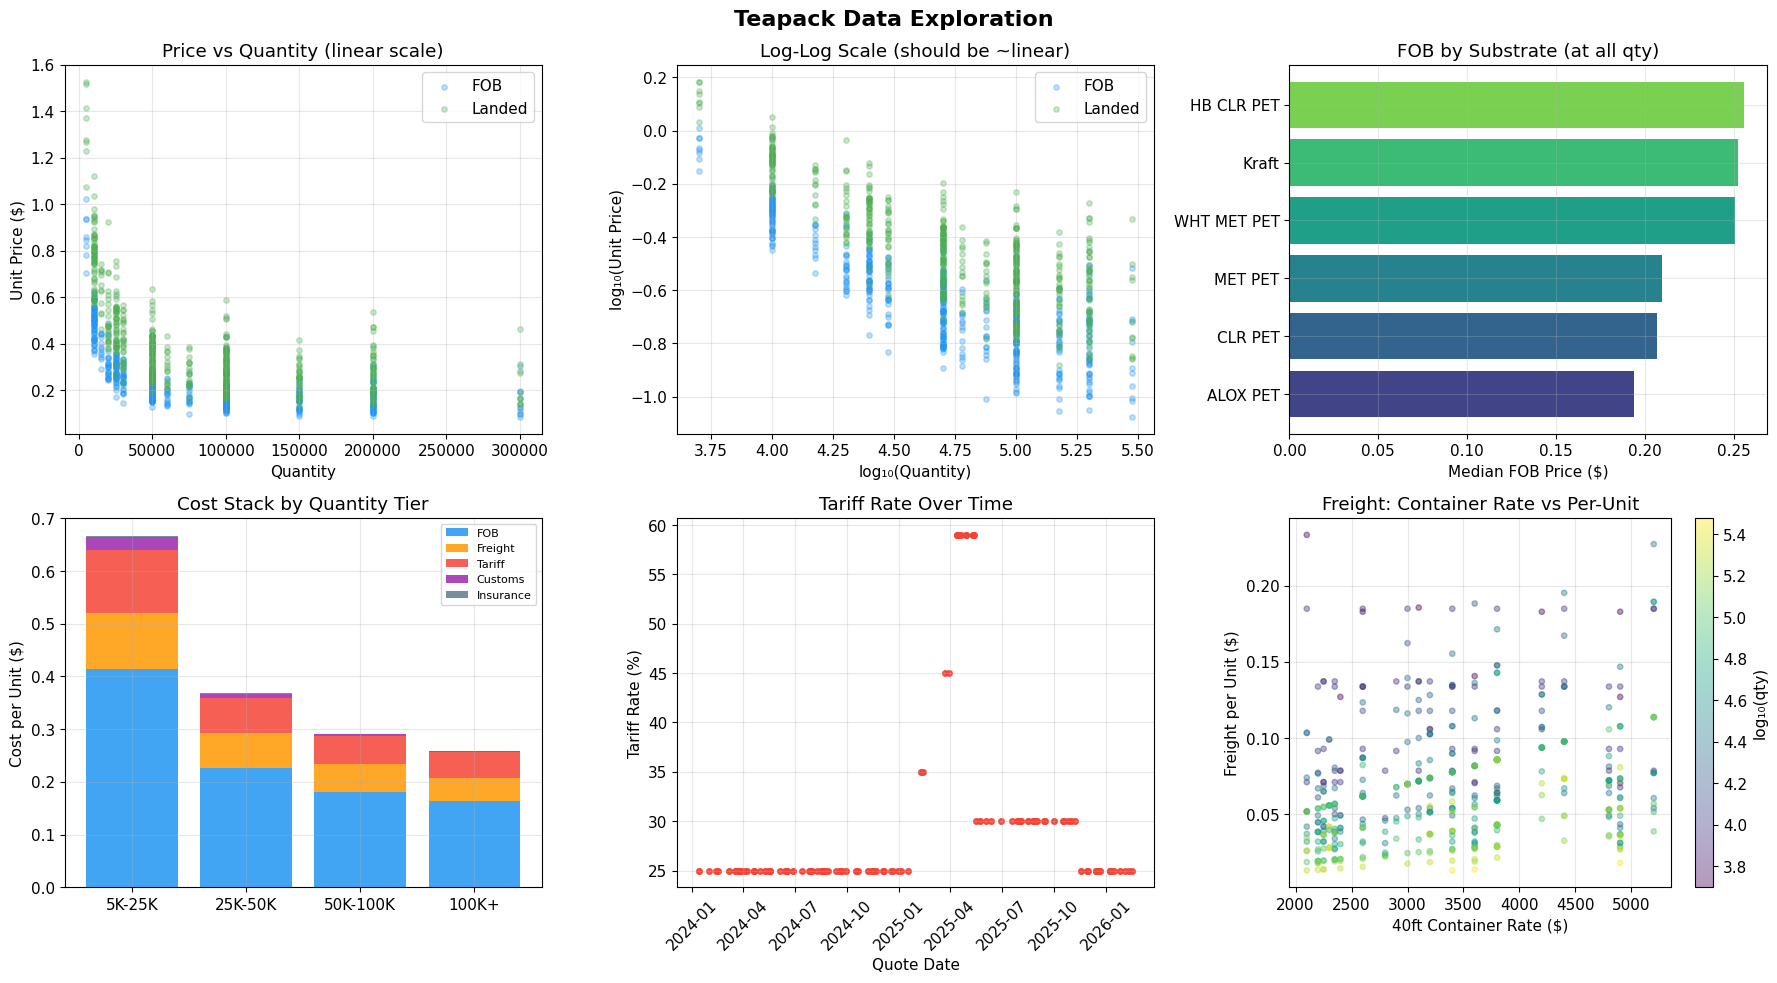

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 3: DATA VISUALIZATION — UNDERSTANDING THE CURVE
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 3 — Visualize price curves & cost structure**

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Teapack Data Exploration", fontsize=16, fontweight='bold')

# ── 3a: Price vs Quantity (the fundamental curve) ────────────────────────────
# This should show the hyperbolic drop: steep at low qty, flat at high qty
ax = axes[0, 0]
ax.scatter(df['quantity'], df['fob_unit_price'], alpha=0.3, s=15, c='#2196F3', label='FOB')
ax.scatter(df['quantity'], df['landed_unit_cost'], alpha=0.3, s=15, c='#4CAF50', label='Landed')
ax.set_xlabel('Quantity')
ax.set_ylabel('Unit Price ($)')
ax.set_title('Price vs Quantity (linear scale)')
ax.legend()

# ── 3b: Same but log-log scale (should be roughly linear) ───────────────────
# If this looks linear, it confirms the power-law relationship:
#   log(price) = A - B × log(qty)  →  price = 10^A × qty^(-B)
ax = axes[0, 1]
ax.scatter(np.log10(df['quantity']), np.log10(df['fob_unit_price']),
           alpha=0.3, s=15, c='#2196F3', label='FOB')
ax.scatter(np.log10(df['quantity']), np.log10(df['landed_unit_cost']),
           alpha=0.3, s=15, c='#4CAF50', label='Landed')
ax.set_xlabel('log₁₀(Quantity)')
ax.set_ylabel('log₁₀(Unit Price)')
ax.set_title('Log-Log Scale (should be ~linear)')
ax.legend()

# ── 3c: FOB price distribution by substrate ─────────────────────────────────
ax = axes[0, 2]
substrates = df.groupby('substrate')['fob_unit_price'].median().sort_values()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(substrates)))
ax.barh(range(len(substrates)), substrates.values, color=colors)
ax.set_yticks(range(len(substrates)))
ax.set_yticklabels(substrates.index)
ax.set_xlabel('Median FOB Price ($)')
ax.set_title('FOB by Substrate (at all qty)')

# ── 3d: Cost stack breakdown by quantity tier ────────────────────────────────
ax = axes[1, 0]
qty_bins = pd.cut(df['quantity'], bins=[0, 25000, 50000, 100000, 500000],
                  labels=['5K-25K', '25K-50K', '50K-100K', '100K+'])
stack_data = df.assign(qty_bin=qty_bins).groupby('qty_bin').agg({
    'fob_unit_price': 'mean',
    'freight_per_unit': 'mean',
    'customs_per_unit': 'mean',
    'insurance_per_unit': 'mean'
}).reset_index()
# Compute tariff separately since it's a derived column
stack_data['tariff_per_unit'] = df.assign(qty_bin=qty_bins).groupby('qty_bin').apply(
    lambda g: (g['fob_unit_price'] * g['tariff_rate']).mean()
).values

x = range(len(stack_data))
bottoms = np.zeros(len(stack_data))
for label, col, color in [('FOB', 'fob_unit_price', '#2196F3'),
                            ('Freight', 'freight_per_unit', '#FF9800'),
                            ('Tariff', 'tariff_per_unit', '#F44336'),
                            ('Customs', 'customs_per_unit', '#9C27B0'),
                            ('Insurance', 'insurance_per_unit', '#607D8B')]:
    vals = stack_data[col].values
    ax.bar(x, vals, bottom=bottoms, label=label, color=color, alpha=0.85)
    bottoms += vals
ax.set_xticks(x)
ax.set_xticklabels(stack_data['qty_bin'])
ax.set_ylabel('Cost per Unit ($)')
ax.set_title('Cost Stack by Quantity Tier')
ax.legend(fontsize=8)

# ── 3e: Tariff rate impact over time ────────────────────────────────────────
ax = axes[1, 1]
df_sorted = df.sort_values('quote_date')
ax.scatter(pd.to_datetime(df_sorted['quote_date']), df_sorted['tariff_rate'] * 100,
           alpha=0.4, s=15, c='#F44336')
ax.set_xlabel('Quote Date')
ax.set_ylabel('Tariff Rate (%)')
ax.set_title('Tariff Rate Over Time')
ax.tick_params(axis='x', rotation=45)

# ── 3f: Freight rate vs container rate ──────────────────────────────────────
ax = axes[1, 2]
scatter = ax.scatter(df['container_rate_40ft'], df['freight_per_unit'],
                     c=np.log10(df['quantity']), cmap='viridis', alpha=0.4, s=15)
plt.colorbar(scatter, ax=ax, label='log₁₀(qty)')
ax.set_xlabel('40ft Container Rate ($)')
ax.set_ylabel('Freight per Unit ($)')
ax.set_title('Freight: Container Rate vs Per-Unit')

plt.tight_layout()
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 4: FEATURE ENGINEERING PIPELINE
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 4 — Feature engineering (matching existing Calyx pipeline)**

# ── Define feature columns ───────────────────────────────────────────────────
# These match the 24-feature pipeline from the existing Ross/Dazpak models,
# plus 3 new Teapack-specific features for the landed-cost decomposition.

NUMERIC_FEATURES = [
    # Base bag features (8)
    'width', 'height', 'gusset', 'print_width', 'bag_area_sqin',
    'quantity', 'log_quantity', 'inv_quantity',
    # Interaction features (3)
    'area_x_logqty', 'has_gusset', 'zipper_score',
    # Teapack-specific features (4)
    'has_zipper', 'zipper_width', 'print_area_msi', 'estimated_weight_g',
]

CATEGORICAL_FEATURES = [
    'substrate', 'finish', 'fill_style', 'seal_type', 'gusset_type',
    'zipper', 'tear_notch', 'hole_punch', 'corner_treatment', 'embellishment',
]

# External cost features — used only for the LANDED cost model
# The FOB model should NOT see these (Teapack doesn't know your freight costs)
EXTERNAL_FEATURES = [
    'tariff_rate', 'freight_per_unit', 'fx_cnyusd',
    'customs_per_unit', 'insurance_per_unit',
]

# ── Ordinal encoding for categoricals ────────────────────────────────────────
# We encode from cheapest to most expensive so the ordinal values carry
# meaningful information for tree-based models (higher = pricier).

ORDINAL_MAPPINGS = {
    'substrate':         ['CLR PET', 'MET PET', 'Kraft', 'WHT MET PET', 'ALOX PET', 'HB CLR PET'],
    'finish':            ['None', 'Gloss', 'Matte', 'Soft Touch'],
    'fill_style':        ['Top Fill', 'Bottom Fill', 'Side Fill'],
    'seal_type':         ['Back Seal', '3-Side Seal', 'Stand Up Pouch', 'Flat Bottom', 'Quad Seal'],
    'gusset_type':       ['None', 'Plow', 'K-Seal', 'Box Bottom'],
    'zipper':            ['None', 'Press to Close', 'Slider', 'Velcro', 'Child Resistant'],
    'tear_notch':        ['None', 'Standard', 'Laser Score'],
    'hole_punch':        ['None', 'Standard', 'Euro Slot'],
    'corner_treatment':  ['None', 'Rounded', 'Doyen', 'Butterfly'],
    'embellishment':     ['None', 'Spot UV', 'Emboss', 'Foil Stamp', 'Window'],
}

def encode_features(df, fit=True, encoder=None):
    """
    Encode categorical features using ordinal encoding.

    Why ordinal and not one-hot? Tree-based models (GBR) can split on
    ordinal values efficiently. One-hot encoding creates sparse features
    that fragment the data and require deeper trees to capture the same
    relationships. Since we've ordered categories from cheapest to most
    expensive, a single split like "substrate > 3" meaningfully separates
    premium substrates from standard ones.

    Returns the encoded DataFrame and the fitted encoder (for reuse at
    prediction time).
    """
    df_encoded = df.copy()

    if fit:
        encoder = OrdinalEncoder(
            categories=[ORDINAL_MAPPINGS[col] for col in CATEGORICAL_FEATURES],
            handle_unknown='use_encoded_value',
            unknown_value=-1  # unseen categories get -1
        )
        df_encoded[CATEGORICAL_FEATURES] = encoder.fit_transform(
            df_encoded[CATEGORICAL_FEATURES]
        )
    else:
        df_encoded[CATEGORICAL_FEATURES] = encoder.transform(
            df_encoded[CATEGORICAL_FEATURES]
        )

    return df_encoded, encoder


# ── Apply encoding ───────────────────────────────────────────────────────────
df_encoded, ordinal_encoder = encode_features(df)

# Build feature matrices for both model types
ALL_FEATURES_FOB = NUMERIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES_LANDED = NUMERIC_FEATURES + CATEGORICAL_FEATURES + EXTERNAL_FEATURES

X_fob = df_encoded[ALL_FEATURES_FOB].values
X_landed = df_encoded[ALL_FEATURES_LANDED].values
y_fob = df_encoded['fob_unit_price'].values
y_landed = df_encoded['landed_unit_cost'].values

print(f"✓ Feature matrix shapes:")
print(f"  FOB model:    X={X_fob.shape}, y={y_fob.shape}")
print(f"  Landed model: X={X_landed.shape}, y={y_landed.shape}")
print(f"  Numeric features:     {len(NUMERIC_FEATURES)}")
print(f"  Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"  External features:    {len(EXTERNAL_FEATURES)}")
print(f"  Total FOB features:   {len(ALL_FEATURES_FOB)}")
print(f"  Total landed features:{len(ALL_FEATURES_LANDED)}")

✓ Feature matrix shapes:
  FOB model:    X=(499, 25), y=(499,)
  Landed model: X=(499, 30), y=(499,)
  Numeric features:     15
  Categorical features: 10
  External features:    5
  Total FOB features:   25
  Total landed features:30


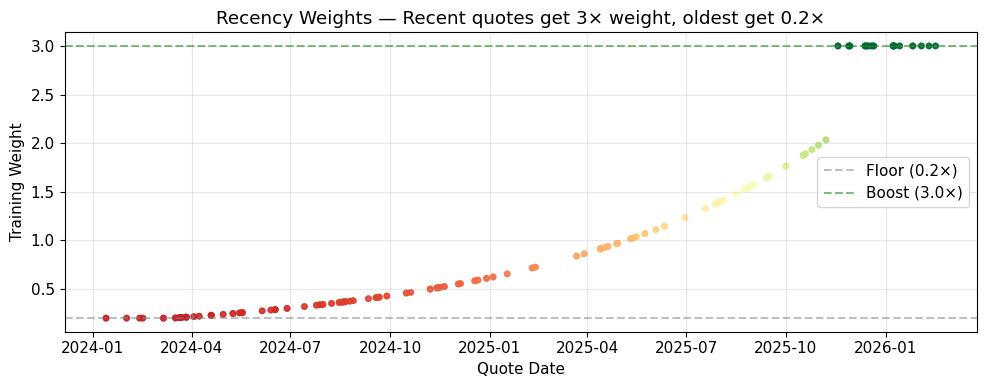

Weight distribution: min=0.20, median=0.61, max=3.00


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 5: RECENCY WEIGHTING
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 5 — Recency weighting (newer quotes matter more)**

def compute_recency_weights(quote_dates, boost_days=90, half_life_days=180,
                            floor_weight=0.2, max_weight=3.0):
    """
    Weight training samples by how recent they are.

    WHY THIS MATTERS: Teapack's prices change over time due to material
    cost fluctuations, CNY/USD exchange rate movements, and competitive
    pressure. A quote from 6 months ago is less informative about today's
    pricing than a quote from last week. But we don't want to throw away
    old data entirely — it still tells us about the cost *structure*.

    The weighting scheme:
      - Quotes within the boost window (last 90 days): full weight (3.0×)
      - Older quotes: exponential decay with 180-day half-life
      - Floor: even the oldest quotes get 0.2× weight (never fully ignored)

    The exponential decay formula is:
      weight = max_weight × 2^(-age_days / half_life_days)

    This means after one half-life (180 days), weight drops to 1.5×.
    After two half-lives (360 days), weight drops to 0.75×. And so on,
    until it hits the floor at 0.2×.
    """
    dates = pd.to_datetime(quote_dates)
    reference_date = dates.max()  # most recent quote = reference point

    age_days = (reference_date - dates).dt.days.values

    weights = np.where(
        age_days <= boost_days,
        max_weight,  # recent quotes get full boost
        max_weight * np.power(2.0, -age_days / half_life_days)  # exponential decay
    )

    # Apply floor so old quotes aren't completely ignored
    weights = np.maximum(weights, floor_weight)

    return weights


# ── Compute and visualize weights ────────────────────────────────────────────
sample_weights = compute_recency_weights(df['quote_date'])

fig, ax = plt.subplots(figsize=(10, 4))
dates = pd.to_datetime(df['quote_date'])
ax.scatter(dates, sample_weights, alpha=0.4, s=15, c=sample_weights,
           cmap='RdYlGn', vmin=0, vmax=3)
ax.set_xlabel('Quote Date')
ax.set_ylabel('Training Weight')
ax.set_title('Recency Weights — Recent quotes get 3× weight, oldest get 0.2×')
ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Floor (0.2×)')
ax.axhline(y=3.0, color='green', linestyle='--', alpha=0.5, label='Boost (3.0×)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Weight distribution: min={sample_weights.min():.2f}, "
      f"median={np.median(sample_weights):.2f}, max={sample_weights.max():.2f}")


PARAMETRIC MODEL: price = α/qty + β
  α (fixed cost pool) = $3,536
  β (variable floor)  = $0.1441/unit
  Interpretation: ~$3,536 in fixed costs amortized over the run,
  plus ~$0.1441 per unit in materials/labor that doesn't change with volume.

  MAPE: 20.2%
  R²:   0.847

  This is the BASELINE to beat. The GBR model should do better because
  it can account for spec differences (substrate, zipper, bag size, etc.)


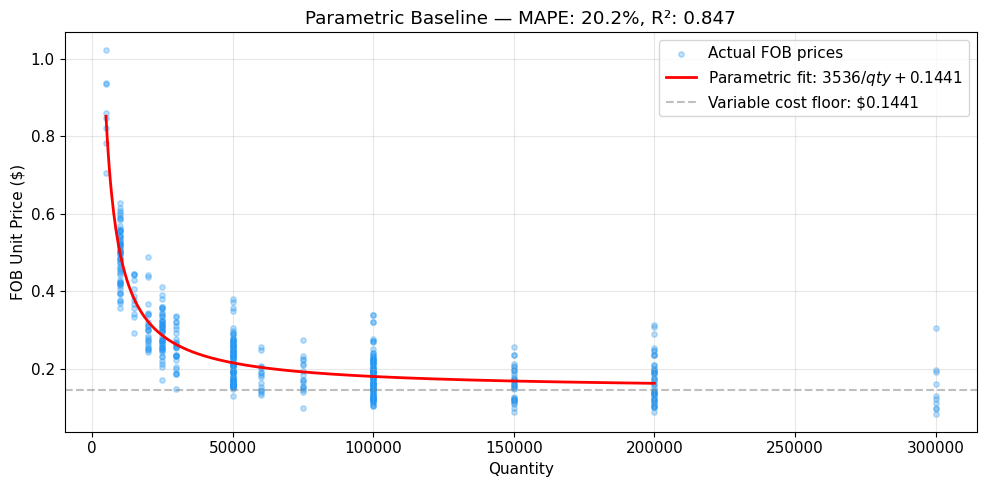

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 6: PARAMETRIC BASELINE MODEL (Curve Fitting)
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 6 — Parametric baseline: unit_price = α/qty + β**

def inverse_qty_model(quantity, alpha, beta):
    """
    The simplest possible pricing model: price = fixed_cost/qty + variable_cost

    This encodes the fundamental economics directly:
      - alpha (α) = total fixed cost that gets amortized across units
      - beta (β) = variable cost floor (material + labor per unit)

    At low quantities, α/qty dominates → prices are high.
    At high quantities, α/qty → 0, and price approaches β → the floor.

    This is our BASELINE. If the GBR model can't beat this, something
    is wrong with our feature engineering.
    """
    return alpha / quantity + beta


# ── Fit the parametric model to the full dataset ─────────────────────────────
# We fit it globally first (ignoring spec differences) to get a baseline
try:
    popt, pcov = curve_fit(
        inverse_qty_model,
        df['quantity'].values,
        df['fob_unit_price'].values,
        p0=[5000, 0.05],           # initial guesses: $5K fixed, $0.05 variable
        bounds=([0, 0], [np.inf, np.inf]),  # both must be positive
        maxfev=10000
    )
    alpha_fit, beta_fit = popt

    # Predict using the fitted parametric model
    y_pred_parametric = inverse_qty_model(df['quantity'].values, alpha_fit, beta_fit)
    mape_parametric = mean_absolute_percentage_error(y_fob, y_pred_parametric) * 100
    r2_parametric = r2_score(y_fob, y_pred_parametric)

    print("PARAMETRIC MODEL: price = α/qty + β")
    print(f"  α (fixed cost pool) = ${alpha_fit:,.0f}")
    print(f"  β (variable floor)  = ${beta_fit:.4f}/unit")
    print(f"  Interpretation: ~${alpha_fit:,.0f} in fixed costs amortized over the run,")
    print(f"  plus ~${beta_fit:.4f} per unit in materials/labor that doesn't change with volume.")
    print(f"\n  MAPE: {mape_parametric:.1f}%")
    print(f"  R²:   {r2_parametric:.3f}")
    print(f"\n  This is the BASELINE to beat. The GBR model should do better because")
    print(f"  it can account for spec differences (substrate, zipper, bag size, etc.)")

    # ── Visualize the fit ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    qty_curve = np.linspace(5000, 200000, 500)
    price_curve = inverse_qty_model(qty_curve, alpha_fit, beta_fit)

    ax.scatter(df['quantity'], df['fob_unit_price'], alpha=0.3, s=15,
               c='#2196F3', label='Actual FOB prices')
    ax.plot(qty_curve, price_curve, 'r-', linewidth=2,
            label=f'Parametric fit: ${alpha_fit:.0f}/qty + ${beta_fit:.4f}')
    ax.axhline(y=beta_fit, color='gray', linestyle='--', alpha=0.5,
               label=f'Variable cost floor: ${beta_fit:.4f}')
    ax.set_xlabel('Quantity')
    ax.set_ylabel('FOB Unit Price ($)')
    ax.set_title(f'Parametric Baseline — MAPE: {mape_parametric:.1f}%, R²: {r2_parametric:.3f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Parametric fit failed: {e}")
    mape_parametric = 999
    print("Continuing to GBR model...")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 7: TRAIN GBR MODELS — FOB PRICE (THE CORE ML)
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 7 — Train GBR models for FOB price prediction**

# ── WHY THREE MODELS ─────────────────────────────────────────────────────────
# Model 1 (point):  Predicts the expected FOB price (Huber loss for robustness)
# Model 2 (lower):  Predicts the 10th percentile (lower confidence bound)
# Model 3 (upper):  Predicts the 90th percentile (upper confidence bound)
#
# Together, models 2+3 form an 80% confidence interval. This tells the
# salesperson: "We're 80% sure the actual price falls between $X and $Y"

# ── Log-transform the target ────────────────────────────────────────────────
# WHY: FOB prices range from $0.08 to $1.00+ (a 12× range). A $0.02 error
# on a $0.08 item is a 25% miss, but the same $0.02 on a $0.50 item is only
# 4%. Training on log(price) makes the model optimize for PERCENTAGE accuracy
# rather than absolute dollar accuracy. This is what you want for quoting.

y_fob_log = np.log10(y_fob)

print("Target distribution:")
print(f"  Raw FOB prices: ${y_fob.min():.4f} — ${y_fob.max():.4f}")
print(f"  Log10 FOB:      {y_fob_log.min():.3f} — {y_fob_log.max():.3f}")

# ── Hyperparameters ──────────────────────────────────────────────────────────
# These are tuned based on the Ross model optimization history (the same
# data scale of ~500 rows). Key choices:
#
# n_estimators=400:  Enough trees to capture complex interactions, but not
#                    so many that we overfit 500 rows.
# max_depth=5:       Each tree can ask 5 questions. This captures interactions
#                    like "width > 6 AND has_zipper AND qty > 50K AND substrate > 3"
# learning_rate=0.03: Conservative — each tree makes small corrections.
#                     Prevents overfitting and works well with Huber loss.
# min_samples_leaf=4: At least 4 training examples must land in each leaf.
#                     With 500 rows, this prevents rules based on 1-2 data points.
# subsample=0.8:     Each tree sees a random 80% of data. Adds regularization.
# loss='huber':      Robust to outliers — switches from squared to linear
#                    penalty for large errors. Critical for noisy vendor data.

HYPERPARAMS = {
    'n_estimators': 400,
    'max_depth': 5,
    'learning_rate': 0.03,
    'min_samples_leaf': 4,
    'subsample': 0.8,
    'random_state': 42,
}

# ── Train the three models ───────────────────────────────────────────────────
print("\nTraining FOB price models on log-transformed target...")
print(f"  Features: {X_fob.shape[1]} | Samples: {X_fob.shape[0]}")

# Point prediction (Huber loss — robust to outliers)
model_fob_point = GradientBoostingRegressor(
    loss='huber', **HYPERPARAMS
)
model_fob_point.fit(X_fob, y_fob_log, sample_weight=sample_weights)

# Lower bound (10th percentile — quantile regression)
model_fob_lower = GradientBoostingRegressor(
    loss='quantile', alpha=0.10, **HYPERPARAMS
)
model_fob_lower.fit(X_fob, y_fob_log, sample_weight=sample_weights)

# Upper bound (90th percentile — quantile regression)
model_fob_upper = GradientBoostingRegressor(
    loss='quantile', alpha=0.90, **HYPERPARAMS
)
model_fob_upper.fit(X_fob, y_fob_log, sample_weight=sample_weights)

# ── Evaluate on training data ────────────────────────────────────────────────
# NOTE: this is training-set performance, NOT generalization performance.
# We'll do proper cross-validation in the next block. This is just a sanity check.

y_pred_log = model_fob_point.predict(X_fob)
y_pred_fob = 10 ** y_pred_log           # inverse log transform back to dollars
y_pred_lower = 10 ** model_fob_lower.predict(X_fob)
y_pred_upper = 10 ** model_fob_upper.predict(X_fob)

mape_train = mean_absolute_percentage_error(y_fob, y_pred_fob) * 100
r2_train = r2_score(y_fob, y_pred_fob)
mae_train = mean_absolute_error(y_fob, y_pred_fob)

# CI coverage: what % of actual prices fall within the predicted 80% CI?
ci_coverage = np.mean((y_fob >= y_pred_lower) & (y_fob <= y_pred_upper)) * 100

print(f"\n{'═' * 50}")
print(f"FOB MODEL — TRAINING SET PERFORMANCE")
print(f"{'═' * 50}")
print(f"  MAPE:         {mape_train:.1f}%")
print(f"  R²:           {r2_train:.3f}")
print(f"  MAE:          ${mae_train:.4f}")
print(f"  80% CI cover: {ci_coverage:.1f}%")
print(f"  vs Parametric: {mape_parametric:.1f}% MAPE (baseline)")
print(f"  Improvement:   {mape_parametric - mape_train:.1f}pp better")

Target distribution:
  Raw FOB prices: $0.0837 — $1.0211
  Log10 FOB:      -1.077 — 0.009

Training FOB price models on log-transformed target...
  Features: 25 | Samples: 499

══════════════════════════════════════════════════
FOB MODEL — TRAINING SET PERFORMANCE
══════════════════════════════════════════════════
  MAPE:         2.3%
  R²:           0.990
  MAE:          $0.0066
  80% CI cover: 75.4%
  vs Parametric: 20.2% MAPE (baseline)
  Improvement:   17.9pp better


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 8: CROSS-VALIDATION (TEMPORAL)
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 8 — Time-series cross-validation (honest evaluation)**

# ── WHY TEMPORAL CV AND NOT RANDOM? ──────────────────────────────────────────
# In production, you'll train on past quotes and predict FUTURE prices.
# Random train/test splits let the model "cheat" by learning from future data
# that it wouldn't have in reality. Temporal CV simulates the real scenario:
# train on everything before a cutoff, test on everything after.

# Sort by date for temporal splitting
df_sorted = df_encoded.sort_values('quote_date').reset_index(drop=True)
X_sorted = df_sorted[ALL_FEATURES_FOB].values
y_sorted = np.log10(df_sorted['fob_unit_price'].values)
weights_sorted = compute_recency_weights(df_sorted['quote_date'])

# TimeSeriesSplit creates expanding windows:
# Fold 1: train on [0:100], test on [100:200]
# Fold 2: train on [0:200], test on [200:300]
# etc.
tscv = TimeSeriesSplit(n_splits=5)

fold_mapes = []
fold_r2s = []
fold_coverages = []

print("Temporal Cross-Validation (5 folds)")
print(f"{'─' * 60}")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_sorted)):
    X_train, X_test = X_sorted[train_idx], X_sorted[test_idx]
    y_train, y_test = y_sorted[train_idx], y_sorted[test_idx]
    w_train = weights_sorted[train_idx]

    # Train point model on this fold
    m = GradientBoostingRegressor(loss='huber', **HYPERPARAMS)
    m.fit(X_train, y_train, sample_weight=w_train)

    # Train CI models on this fold
    m_lo = GradientBoostingRegressor(loss='quantile', alpha=0.10, **HYPERPARAMS)
    m_lo.fit(X_train, y_train, sample_weight=w_train)
    m_hi = GradientBoostingRegressor(loss='quantile', alpha=0.90, **HYPERPARAMS)
    m_hi.fit(X_train, y_train, sample_weight=w_train)

    # Evaluate
    y_pred = 10 ** m.predict(X_test)
    y_actual = 10 ** y_test
    y_lo = 10 ** m_lo.predict(X_test)
    y_hi = 10 ** m_hi.predict(X_test)

    mape = mean_absolute_percentage_error(y_actual, y_pred) * 100
    r2 = r2_score(y_actual, y_pred)
    coverage = np.mean((y_actual >= y_lo) & (y_actual <= y_hi)) * 100

    fold_mapes.append(mape)
    fold_r2s.append(r2)
    fold_coverages.append(coverage)

    train_dates = df_sorted.iloc[train_idx]['quote_date']
    test_dates = df_sorted.iloc[test_idx]['quote_date']

    print(f"  Fold {fold+1}: train {train_dates.min()}→{train_dates.max()} "
          f"({len(train_idx)} rows) | test {test_dates.min()}→{test_dates.max()} "
          f"({len(test_idx)} rows)")
    print(f"          MAPE: {mape:.1f}%  R²: {r2:.3f}  CI coverage: {coverage:.1f}%")

print(f"\n{'═' * 60}")
print(f"AVERAGE ACROSS FOLDS (this is the honest performance estimate):")
print(f"  MAPE:     {np.mean(fold_mapes):.1f}% ± {np.std(fold_mapes):.1f}%")
print(f"  R²:       {np.mean(fold_r2s):.3f} ± {np.std(fold_r2s):.3f}")
print(f"  CI cover: {np.mean(fold_coverages):.1f}%")
print(f"\nTarget: MAPE < 10%, R² > 0.85, CI coverage > 75%")



Temporal Cross-Validation (5 folds)
────────────────────────────────────────────────────────────
  Fold 1: train 2024-01-13→2024-05-15 (84 rows) | test 2024-05-15→2024-08-28 (83 rows)
          MAPE: 11.7%  R²: 0.792  CI coverage: 45.8%
  Fold 2: train 2024-01-13→2024-08-28 (167 rows) | test 2024-08-28→2024-12-29 (83 rows)
          MAPE: 8.5%  R²: 0.945  CI coverage: 39.8%
  Fold 3: train 2024-01-13→2024-12-29 (250 rows) | test 2025-01-04→2025-06-11 (83 rows)
          MAPE: 7.8%  R²: 0.903  CI coverage: 53.0%
  Fold 4: train 2024-01-13→2025-06-11 (333 rows) | test 2025-06-11→2025-10-31 (83 rows)
          MAPE: 7.4%  R²: 0.931  CI coverage: 47.0%
  Fold 5: train 2024-01-13→2025-10-31 (416 rows) | test 2025-10-31→2026-02-16 (83 rows)
          MAPE: 7.1%  R²: 0.968  CI coverage: 60.2%

════════════════════════════════════════════════════════════
AVERAGE ACROSS FOLDS (this is the honest performance estimate):
  MAPE:     8.5% ± 1.6%
  R²:       0.908 ± 0.062
  CI cover: 49.2%

Target: 

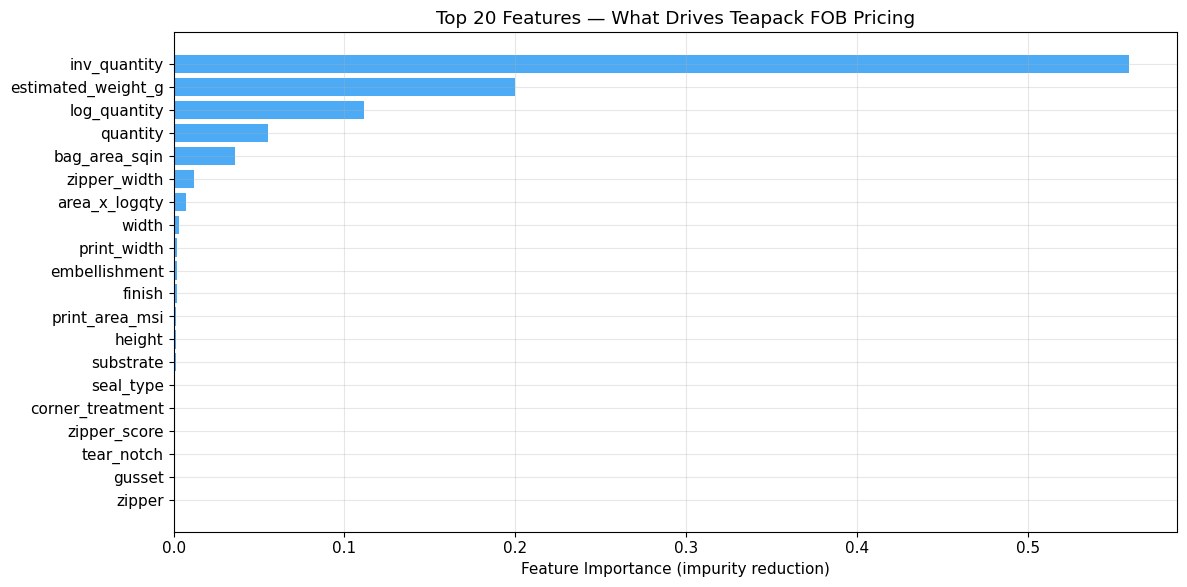

Top 10 features by importance:
   1. inv_quantity          0.5594
   2. estimated_weight_g    0.1998
   3. log_quantity          0.1112
   4. quantity              0.0550
   5. bag_area_sqin         0.0360
   6. zipper_width          0.0122
   7. area_x_logqty         0.0073
   8. width                 0.0029
   9. print_width           0.0021
  10. embellishment         0.0020


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 9: FEATURE IMPORTANCE ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 9 — Which features drive Teapack's pricing?**

importance = model_fob_point.feature_importances_
feature_names = ALL_FEATURES_FOB
sorted_idx = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
top_n = 20
ax.barh(range(top_n), importance[sorted_idx[:top_n]][::-1],
        color='#2196F3', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]][::-1])
ax.set_xlabel('Feature Importance (impurity reduction)')
ax.set_title('Top 20 Features — What Drives Teapack FOB Pricing')
plt.tight_layout()
plt.show()

print("Top 10 features by importance:")
for rank, idx in enumerate(sorted_idx[:10]):
    print(f"  {rank+1:2d}. {feature_names[idx]:20s}  {importance[idx]:.4f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 10: THE PENNY-STEP ALGORITHM
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 10 — Penny-step curve generation**

def generate_prediction_grid(spec_dict, models, encoder, tariff_rate,
                              container_rate, fx_rate,
                              min_qty=5000, max_qty=200000, n_points=500):
    """
    Generate a dense grid of landed-cost predictions for one bag spec.

    This is the core algorithm that powers the interactive price curve.
    It combines ML predictions (for FOB) with deterministic calculations
    (for freight, tariff, customs, insurance) to produce the full landed
    cost at every quantity point.

    We use LOGARITHMIC spacing for the quantity grid because price changes
    are percentage-based, not absolute. A 1,000-unit increase matters a lot
    at 5,000 (20% more) but is negligible at 200,000 (0.5% more).
    """
    # ── Generate log-spaced quantity points ──────────────────────────────
    quantities = np.logspace(
        np.log10(min_qty),
        np.log10(max_qty),
        n_points
    ).astype(int)
    quantities = np.unique(quantities)  # remove duplicates from rounding

    predictions = []

    for qty in quantities:
        # ── Build feature vector for this (spec, qty) combination ────────
        row = spec_dict.copy()
        row['quantity'] = qty
        row['log_quantity'] = math.log10(qty)
        row['inv_quantity'] = 1.0 / qty
        row['area_x_logqty'] = row['bag_area_sqin'] * row['log_quantity']

        # Build a single-row DataFrame matching the feature pipeline
        row_df = pd.DataFrame([row])

        # Encode categoricals using the fitted encoder
        row_encoded, _ = encode_features(row_df, fit=False, encoder=encoder)
        X = row_encoded[ALL_FEATURES_FOB].values

        # ── ML predictions (FOB price in log-space) ─────────────────────
        fob_log = models['point'].predict(X)[0]
        fob_lower_log = models['lower'].predict(X)[0]
        fob_upper_log = models['upper'].predict(X)[0]

        # Inverse transform back to dollar space
        fob_point = 10 ** fob_log
        fob_lower = 10 ** fob_lower_log
        fob_upper = 10 ** fob_upper_log

        # ── Deterministic cost components ────────────────────────────────
        # These are CALCULATED, not predicted — no ML uncertainty here

        # Freight (simplified — full version would use the freight calculator)
        # Rule of thumb: $0.02-0.06/unit depending on qty and bag size
        base_freight = container_rate / max(qty * 0.8, 1000)
        freight = max(base_freight, 0.005)  # floor

        # Tariff = FOB × tariff_rate
        tariff = fob_point * tariff_rate

        # Customs brokerage (amortized)
        customs = (285.0 + 35.0) / qty

        # Insurance (0.4% of CIF)
        insurance = (fob_point + freight) * 0.004

        # ── LANDED COST ─────────────────────────────────────────────────
        landed = fob_point + freight + tariff + customs + insurance
        landed_lower = fob_lower + freight + fob_lower * tariff_rate + customs + (fob_lower + freight) * 0.004
        landed_upper = fob_upper + freight + fob_upper * tariff_rate + customs + (fob_upper + freight) * 0.004

        predictions.append({
            'qty': qty,
            'fob_point': round(fob_point, 5),
            'fob_lower': round(fob_lower, 5),
            'fob_upper': round(fob_upper, 5),
            'freight': round(freight, 5),
            'tariff': round(tariff, 5),
            'customs': round(customs, 5),
            'insurance': round(insurance, 5),
            'landed': round(landed, 5),
            'landed_lower': round(landed_lower, 5),
            'landed_upper': round(landed_upper, 5),
        })

    return pd.DataFrame(predictions)


def extract_penny_steps(predictions_df, price_col='landed'):
    """
    Extract the quantity points where the rounded-to-2dp price changes.

    THE KEY INSIGHT: between two adjacent penny steps, the rounded price
    is the same. So there's no point showing the customer quantities
    within that range — they all display as the same dollar amount.

    Each returned step represents a CLICKABLE NODE on the interactive chart.
    The step tells you: "At this quantity, the price drops to $X.XX. The
    NEXT price drop to $X.(XX-1) happens at [the next step's quantity]."
    """
    steps = []
    current_penny = None

    for _, row in predictions_df.iterrows():
        rounded = round(row[price_col], 2)
        if rounded != current_penny:
            steps.append({
                'qty': int(row['qty']),
                'landed': rounded,
                'fob': round(row['fob_point'], 4),
                'fob_lower': round(row['fob_lower'], 4),
                'fob_upper': round(row['fob_upper'], 4),
                'freight': round(row['freight'], 4),
                'tariff': round(row['tariff'], 4),
                'customs': round(row['customs'], 4),
                'insurance': round(row['insurance'], 4),
                'landed_lower': round(row['landed_lower'], 2),
                'landed_upper': round(row['landed_upper'], 2),
            })
            current_penny = rounded

    return pd.DataFrame(steps)


print("✓ Penny-step algorithm defined")
print("  generate_prediction_grid() — dense landed-cost predictions")
print("  extract_penny_steps() — find $0.01 price-break boundaries")


✓ Penny-step algorithm defined
  generate_prediction_grid() — dense landed-cost predictions
  extract_penny_steps() — find $0.01 price-break boundaries


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 11: GENERATE A QUOTE (END-TO-END DEMO)
# ═══════════════════════════════════════════════════════════════════════════════

#@title **Block 11 — Run a Full Quote (change the spec here!)**

SPEC = {
    'width': 6.0, 'height': 8.0, 'gusset': 1.5,
    'print_width': 8.0 * 2 + 1.5,
    'bag_area_sqin': 6.0 * 8.0,
    'substrate': 'MET PET', 'finish': 'Matte',
    'fill_style': 'Top Fill', 'seal_type': 'Stand Up Pouch',
    'gusset_type': 'K-Seal', 'zipper': 'Press to Close',
    'tear_notch': 'Standard', 'hole_punch': 'None',
    'corner_treatment': 'Rounded', 'embellishment': 'None',
    'has_gusset': 1, 'has_zipper': 1, 'zipper_score': 1.0,
    'zipper_width': 6.0,
    'print_area_msi': (8.0 * 2 + 1.5) * 8.0 / 1000,
    'estimated_weight_g': 48 * 2 * 0.12 + 1.5 * 8 * 2 * 0.12 + 2.5,
}

TARIFF  = 0.35
FREIGHT = 2300
FX      = 0.1372

models_dict = {'point': model_fob_point, 'lower': model_fob_lower,
               'upper': model_fob_upper}

print(f"Generating quote for {SPEC['width']}W × {SPEC['height']}H × "
      f"{SPEC['gusset']}G  |  {SPEC['substrate']} / {SPEC['finish']}  |  "
      f"{SPEC['zipper']}")
print(f"Tariff {TARIFF*100:.0f}% | Container ${FREIGHT} | FX {FX}")

grid = generate_prediction_grid(SPEC, models_dict, ordinal_encoder,
                                 TARIFF, FREIGHT, FX)
penny_steps = extract_penny_steps(grid)

# Check actual column names
ci_lo_col = 'landed_lo' if 'landed_lo' in penny_steps.columns else 'landed_lower'
ci_hi_col = 'landed_hi' if 'landed_hi' in penny_steps.columns else 'landed_upper'

print(f"\n✓ {len(grid)} prediction points → {len(penny_steps)} penny-step breaks")
print(f"  Price range: ${penny_steps['landed'].max():.2f} → "
      f"${penny_steps['landed'].min():.2f}")
print(f"  Quantity range: {int(penny_steps['qty'].min()):,} → "
      f"{int(penny_steps['qty'].max()):,}")

print(f"\n{'Qty':>10s}  {'Landed':>8s}  {'FOB':>8s}  {'Freight':>8s}  "
      f"{'Tariff':>8s}  {'80% CI':>14s}")
print("─" * 68)
for _, r in penny_steps.head(20).iterrows():
    print(f"{int(r['qty']):>10,d}  ${r['landed']:>6.2f}  ${r['fob']:.4f}  "
          f"${r['freight']:.4f}  ${r['tariff']:.4f}  "
          f"${r[ci_lo_col]:.2f}–${r[ci_hi_col]:.2f}")
if len(penny_steps) > 20:
    print(f"  ... and {len(penny_steps) - 20} more steps")

Generating quote for 6.0W × 8.0H × 1.5G  |  MET PET / Matte  |  Press to Close
Tariff 35% | Container $2300 | FX 0.1372

✓ 500 prediction points → 83 penny-step breaks
  Price range: $1.75 → $0.19
  Quantity range: 4,999 → 173,791

       Qty    Landed       FOB   Freight    Tariff          80% CI
────────────────────────────────────────────────────────────────────
     4,999  $  1.75  $0.8158  $0.5751  $0.2855  $1.22–$1.74
     5,037  $  1.74  $0.8158  $0.5708  $0.2855  $1.21–$1.73
     5,112  $  1.73  $0.8158  $0.5624  $0.2855  $1.20–$1.72
     5,188  $  1.72  $0.8158  $0.5542  $0.2855  $1.19–$1.72
     5,265  $  1.71  $0.8158  $0.5461  $0.2855  $1.19–$1.71
     5,343  $  1.70  $0.8158  $0.5381  $0.2855  $1.18–$1.70
     5,463  $  1.69  $0.8146  $0.5263  $0.2851  $1.16–$1.68
     5,504  $  1.68  $0.8139  $0.5224  $0.2849  $1.15–$1.68
     5,627  $  1.67  $0.8139  $0.5109  $0.2849  $1.14–$1.67
     5,711  $  1.66  $0.8139  $0.5034  $0.2849  $1.13–$1.66
     5,839  $  1.65  $0.8139  $0

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 12: INTERACTIVE PENNY-STEP CHART (Plotly)
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 12 — Interactive penny-step price curve**

# ── Build the Plotly chart ───────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.7, 0.3],
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        'Landed Cost Curve (click any penny-step to select quantity)',
        'Cost Breakdown by Component'
    )
)

# ── Top chart: Penny-step price curves ───────────────────────────────────────

# Confidence band (landed cost uncertainty from ML)
fig.add_trace(go.Scatter(
    x=penny_steps['qty'], y=penny_steps['landed_upper'],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip',
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=penny_steps['qty'], y=penny_steps['landed_lower'],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(59, 235, 164, 0.12)',
    name='80% Confidence Band', hoverinfo='skip',
), row=1, col=1)

# FOB price curve (dashed — what Teapack charges)
fig.add_trace(go.Scatter(
    x=penny_steps['qty'], y=penny_steps['fob'],
    mode='lines', name='FOB Price (Teapack)',
    line=dict(color='#90A4AE', width=1.5, dash='dash'),
    hovertemplate='Qty: %{x:,.0f}<br>FOB: $%{y:.4f}<extra></extra>',
), row=1, col=1)

# Landed cost curve (solid — what it actually costs you)
fig.add_trace(go.Scatter(
    x=penny_steps['qty'], y=penny_steps['landed'],
    mode='lines+markers', name='Landed Cost',
    line=dict(color='#3BEBA4', width=2.5, shape='hv'),  # step function
    marker=dict(size=6, color='#3BEBA4', line=dict(width=1, color='#0C0E12')),
    hovertemplate=(
        '<b>%{x:,.0f} units</b><br>'
        'Landed: <b>$%{y:.2f}</b><br>'
        '<extra></extra>'
    ),
), row=1, col=1)

# ── Bottom chart: Cost stack area chart ──────────────────────────────────────
fig.add_trace(go.Scatter(
    x=grid['qty'], y=grid['fob_point'],
    mode='lines', name='FOB', stackgroup='costs',
    line=dict(width=0.5, color='#2196F3'),
    fillcolor='rgba(33, 150, 243, 0.6)',
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=grid['qty'], y=grid['freight'],
    mode='lines', name='Freight', stackgroup='costs',
    line=dict(width=0.5, color='#FF9800'),
    fillcolor='rgba(255, 152, 0, 0.6)',
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=grid['qty'], y=grid['tariff'],
    mode='lines', name='Tariff', stackgroup='costs',
    line=dict(width=0.5, color='#F44336'),
    fillcolor='rgba(244, 67, 54, 0.6)',
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=grid['qty'], y=grid['customs'] + grid['insurance'],
    mode='lines', name='Customs+Ins', stackgroup='costs',
    line=dict(width=0.5, color='#9C27B0'),
    fillcolor='rgba(156, 39, 176, 0.4)',
), row=2, col=1)

# ── Layout ───────────────────────────────────────────────────────────────────
fig.update_layout(
    height=700,
    template='plotly_dark',
    paper_bgcolor='#0C0E12',
    plot_bgcolor='#13161C',
    font=dict(family='JetBrains Mono, monospace', size=11),
    title=dict(
        text=(f"Teapack Landed Cost — {sample_spec['width']}×{sample_spec['height']}×"
              f"{sample_spec['gusset']} {sample_spec['substrate']} / "
              f"{sample_spec['finish']} / {sample_spec['zipper']}<br>"
              f"<sub>Tariff: {current_tariff*100:.0f}% | Container: "
              f"${current_container_rate} SHA→LA | {len(penny_steps)} price breaks</sub>"),
        font=dict(size=14),
    ),
    legend=dict(orientation='h', y=1.02, x=0.5, xanchor='center'),
    hovermode='x unified',
)

fig.update_xaxes(title_text='Quantity', row=2, col=1, gridcolor='#23272F')
fig.update_yaxes(title_text='Unit Price ($)', row=1, col=1, gridcolor='#23272F',
                 tickformat='$.2f')
fig.update_yaxes(title_text='Cost/Unit ($)', row=2, col=1, gridcolor='#23272F',
                 tickformat='$.3f')
fig.update_xaxes(gridcolor='#23272F')

fig.show()


TARIFF SCENARIO MODELER — 50,000 units
Spec: 6.0×8.0×1.5 MET PET
══════════════════════════════════════════════════════════════════════
Scenario                  Rate       FOB    Tariff    Landed   Order Total
──────────────────────────────────────────────────────────────────────
S.301 Removed              15%  $0.1688  $0.0253  $0.2590  $     12,948
Current (Feb 2026)         35%  $0.1688  $0.0591  $0.2927  $     14,636 ◄
Truce Expires              45%  $0.1688  $0.0760  $0.3096  $     15,480
Full Escalation            55%  $0.1688  $0.0929  $0.3265  $     16,324

Exposure range: $3,376 across scenarios
That's a 23.1% swing on order value


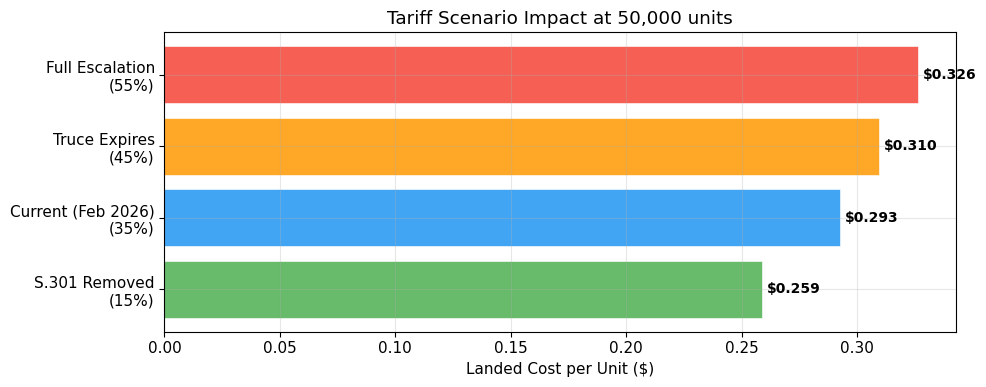

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 13: TARIFF SCENARIO MODELER
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 13 — Tariff scenario modeler (auto-calculated, no slider)**

def model_tariff_scenarios(spec_dict, models, encoder, container_rate,
                            fx_rate, target_qty=50000):
    """
    Calculate landed cost under different tariff scenarios at a fixed quantity.

    These aren't hypotheticals — they're real policy outcomes:
      - S.301 removed: if Biden-era tariffs are negotiated away
      - Current: what's in effect today (Feb 2026)
      - Truce expires: if the Nov 2026 extension lapses
      - Full escalation: return to pre-truce peak rates
    """
    scenarios = [
        {"name": "S.301 Removed", "rate": 0.15, "desc": "Only reciprocal + S.122"},
        {"name": "Current (Feb 2026)", "rate": 0.35, "desc": "S.301 25% + S.122 10%"},
        {"name": "Truce Expires", "rate": 0.45, "desc": "S.301 restored + S.122"},
        {"name": "Full Escalation", "rate": 0.55, "desc": "S.301 + IEEPA 20% + Recip"},
    ]

    results = []
    for scenario in scenarios:
        grid = generate_prediction_grid(
            spec_dict, models, encoder,
            tariff_rate=scenario['rate'],
            container_rate=container_rate,
            fx_rate=fx_rate,
            min_qty=target_qty, max_qty=target_qty + 1, n_points=1
        )

        landed = grid.iloc[0]['landed']
        fob = grid.iloc[0]['fob_point']
        tariff_cost = grid.iloc[0]['tariff']
        total_order = landed * target_qty

        results.append({
            **scenario,
            'fob': fob,
            'tariff_cost': tariff_cost,
            'landed': landed,
            'total_order': total_order,
        })

    return pd.DataFrame(results)


# ── Run scenarios ────────────────────────────────────────────────────────────
target_qty = 50000
scenarios = model_tariff_scenarios(
    sample_spec, models, ordinal_encoder,
    current_container_rate, current_fx, target_qty
)

print(f"TARIFF SCENARIO MODELER — {target_qty:,} units")
print(f"Spec: {sample_spec['width']}×{sample_spec['height']}×{sample_spec['gusset']} "
      f"{sample_spec['substrate']}")
print(f"{'═' * 70}")
print(f"{'Scenario':<22s}  {'Rate':>6s}  {'FOB':>8s}  {'Tariff':>8s}  "
      f"{'Landed':>8s}  {'Order Total':>12s}")
print(f"{'─' * 70}")

for _, s in scenarios.iterrows():
    marker = " ◄" if s['name'].startswith('Current') else ""
    print(f"{s['name']:<22s}  {s['rate']*100:5.0f}%  ${s['fob']:.4f}  "
          f"${s['tariff_cost']:.4f}  ${s['landed']:.4f}  "
          f"${s['total_order']:>11,.0f}{marker}")

# Exposure range
exposure = scenarios['total_order'].max() - scenarios['total_order'].min()
print(f"\nExposure range: ${exposure:,.0f} across scenarios")
print(f"That's a {exposure / scenarios['total_order'].iloc[1] * 100:.1f}% swing on order value")

# ── Visualize scenarios ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
bars = ax.barh(range(len(scenarios)), scenarios['landed'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(scenarios)))
ax.set_yticklabels([f"{s['name']}\n({s['rate']*100:.0f}%)" for _, s in scenarios.iterrows()])
ax.set_xlabel('Landed Cost per Unit ($)')
ax.set_title(f'Tariff Scenario Impact at {target_qty:,} units')

# Add value labels
for i, (_, s) in enumerate(scenarios.iterrows()):
    ax.text(s['landed'] + 0.002, i, f"${s['landed']:.3f}", va='center',
            fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 14: VENDOR COMPARISON
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 14 — Vendor comparison (Teapack vs Ross vs Dazpak)**

def vendor_comparison(teapack_landed, teapack_fob, quantity):
    """
    Compare Teapack's landed cost against estimated Ross and Dazpak pricing.

    Since we don't have Ross/Dazpak models loaded here, we use the known
    price ranges from the existing system data:
      - Ross digital (4K-10K):    $0.46-$0.55/unit (landed = same, domestic)
      - Dazpak flexo (75K-200K):  $0.04-$0.12/unit (landed = same, domestic)

    For domestic vendors, landed ≈ quoted price (no tariff, no ocean freight).
    """
    # Ross pricing model (rough — would use actual ML model in production)
    # Ross prices drop with quantity but are higher at all volumes
    ross_base = 0.55  # at 4K
    ross_floor = 0.25  # theoretical floor at very high volume
    ross_price = ross_floor + (ross_base - ross_floor) * (4000 / quantity) ** 0.4
    ross_price = max(ross_price, ross_floor)

    # Dazpak pricing model (MOQ 35K, very competitive at high volumes)
    if quantity < 35000:
        dazpak_price = None  # below MOQ
        dazpak_note = "Below 35K MOQ"
    else:
        dazpak_base = 0.12  # at 35K
        dazpak_floor = 0.04  # at very high volume
        dazpak_price = dazpak_floor + (dazpak_base - dazpak_floor) * (35000 / quantity) ** 0.35

    vendors = [
        {
            'vendor': 'Teapack (China)',
            'fob': teapack_fob,
            'landed': teapack_landed,
            'lead_weeks': 8,
            'moq': 10000,
            'meets_moq': quantity >= 10000,
        },
        {
            'vendor': 'Ross (Digital)',
            'fob': ross_price,
            'landed': ross_price,  # domestic = no tariff/freight
            'lead_weeks': 3,
            'moq': 4000,
            'meets_moq': quantity >= 4000,
        },
    ]

    if dazpak_price is not None:
        vendors.append({
            'vendor': 'Dazpak (Flexo)',
            'fob': dazpak_price,
            'landed': dazpak_price,
            'lead_weeks': 4,
            'moq': 35000,
            'meets_moq': quantity >= 35000,
        })

    return sorted(vendors, key=lambda v: v['landed'])


# ── Run comparison at multiple quantities ────────────────────────────────────
print("VENDOR COMPARISON")
print(f"Spec: {sample_spec['width']}×{sample_spec['height']}×{sample_spec['gusset']} "
      f"{sample_spec['substrate']} / {sample_spec['zipper']}")
print(f"{'═' * 75}")

for qty in [10000, 25000, 50000, 100000]:
    # Get Teapack prediction at this quantity
    grid_single = generate_prediction_grid(
        sample_spec, models, ordinal_encoder,
        current_tariff, current_container_rate, current_fx,
        min_qty=qty, max_qty=qty+1, n_points=1
    )
    tp_landed = grid_single.iloc[0]['landed']
    tp_fob = grid_single.iloc[0]['fob_point']

    comparison = vendor_comparison(tp_landed, tp_fob, qty)

    print(f"\n  At {qty:>7,d} units:")
    print(f"  {'Vendor':<20s}  {'FOB':>8s}  {'Landed':>8s}  {'Lead':>6s}  {'MOQ':>5s}  {'Best?'}")
    print(f"  {'─' * 65}")

    for i, v in enumerate(comparison):
        is_best = "  ★" if i == 0 else ""
        moq_ok = "✓" if v['meets_moq'] else "✗"
        print(f"  {v['vendor']:<20s}  ${v['fob']:.4f}  ${v['landed']:.4f}  "
              f"{v['lead_weeks']:>4d}wk  {moq_ok:>3s}{is_best}")


VENDOR COMPARISON
Spec: 6.0×8.0×1.5 MET PET / Press to Close
═══════════════════════════════════════════════════════════════════════════

  At  10,000 units:
  Vendor                     FOB    Landed    Lead    MOQ  Best?
  ─────────────────────────────────────────────────────────────────
  Ross (Digital)        $0.4579  $0.4579     3wk    ✓  ★
  Teapack (China)       $0.4469  $0.9257     8wk    ✓

  At  25,000 units:
  Vendor                     FOB    Landed    Lead    MOQ  Best?
  ─────────────────────────────────────────────────────────────────
  Ross (Digital)        $0.3941  $0.3941     3wk    ✓  ★
  Teapack (China)       $0.2555  $0.4742     8wk    ✓

  At  50,000 units:
  Vendor                     FOB    Landed    Lead    MOQ  Best?
  ─────────────────────────────────────────────────────────────────
  Dazpak (Flexo)        $0.1106  $0.1106     4wk    ✓  ★
  Teapack (China)       $0.1688  $0.2927     8wk    ✓
  Ross (Digital)        $0.3592  $0.3592     3wk    ✓

  At 100,000 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 15: COMPLETE QUOTE PDF DATA (ready for ReportLab)
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 15 — Generate structured quote output**

def generate_full_quote(spec_dict, quantities, models, encoder,
                        tariff_rate, container_rate, fx_rate):
    """
    Generate a complete quote with all data needed for PDF generation.

    This produces the same structure as your existing generated_quotes
    table in Supabase, extended with the landed-cost decomposition.
    """
    from datetime import datetime

    tier_results = []

    for tier_idx, qty in enumerate(quantities):
        grid = generate_prediction_grid(
            spec_dict, models, encoder,
            tariff_rate, container_rate, fx_rate,
            min_qty=qty, max_qty=qty + 1, n_points=1
        )

        row = grid.iloc[0]
        tier_results.append({
            'tier': tier_idx + 1,
            'quantity': qty,
            'fob_unit': round(row['fob_point'], 4),
            'fob_lower': round(row['fob_lower'], 4),
            'fob_upper': round(row['fob_upper'], 4),
            'freight_unit': round(row['freight'], 4),
            'tariff_unit': round(row['tariff'], 4),
            'customs_unit': round(row['customs'], 5),
            'insurance_unit': round(row['insurance'], 5),
            'landed_unit': round(row['landed'], 4),
            'landed_lower': round(row['landed_lower'], 4),
            'landed_upper': round(row['landed_upper'], 4),
            'landed_total': round(row['landed'] * qty, 2),
        })

    quote = {
        'estimate_number': f"EST-{datetime.now().strftime('%Y%m%d-%H%M%S')}-TP",
        'vendor': 'Teapack',
        'generated_at': datetime.now().isoformat(),
        'spec': spec_dict,
        'external_rates': {
            'tariff_rate': tariff_rate,
            'container_rate_40ft': container_rate,
            'fx_cnyusd': fx_rate,
        },
        'tiers': tier_results,
    }

    return quote


# ── Generate a quote ─────────────────────────────────────────────────────────
customer_quantities = [10000, 25000, 50000, 100000]

quote = generate_full_quote(
    sample_spec, customer_quantities,
    models, ordinal_encoder,
    current_tariff, current_container_rate, current_fx
)

print(f"ESTIMATE: {quote['estimate_number']}")
print(f"Vendor: {quote['vendor']}")
print(f"Generated: {quote['generated_at']}")
print(f"{'═' * 80}")
print(f"\nSpec: {sample_spec['width']}W × {sample_spec['height']}H × "
      f"{sample_spec['gusset']}G")
print(f"      {sample_spec['substrate']} / {sample_spec['finish']} / "
      f"{sample_spec['seal_type']} / {sample_spec['zipper']}")
print(f"\nExternal: Tariff {current_tariff*100:.0f}% | Container ${current_container_rate} | "
      f"FX {current_fx}")
print(f"\n{'Tier':>4s}  {'Qty':>10s}  {'FOB':>8s}  {'Freight':>8s}  {'Tariff':>8s}  "
      f"{'Landed':>8s}  {'80% CI':>14s}  {'Order Total':>12s}")
print(f"{'─' * 85}")

for t in quote['tiers']:
    print(f"{t['tier']:>4d}  {t['quantity']:>10,d}  ${t['fob_unit']:.4f}  "
          f"${t['freight_unit']:.4f}  ${t['tariff_unit']:.4f}  "
          f"${t['landed_unit']:.4f}  "
          f"${t['landed_lower']:.2f}–${t['landed_upper']:.2f}  "
          f"${t['landed_total']:>11,.2f}")


ESTIMATE: EST-20260227-222424-TP
Vendor: Teapack
Generated: 2026-02-27T22:24:24.554061
════════════════════════════════════════════════════════════════════════════════

Spec: 6.0W × 8.0H × 1.5G
      MET PET / Matte / Stand Up Pouch / Press to Close

External: Tariff 35% | Container $2300 | FX 0.1372

Tier         Qty       FOB   Freight    Tariff    Landed          80% CI   Order Total
─────────────────────────────────────────────────────────────────────────────────────
   1      10,000  $0.4469  $0.2875  $0.1564  $0.9257  $0.90–$1.00  $   9,257.40
   2      25,000  $0.2555  $0.1150  $0.0894  $0.4742  $0.46–$0.49  $  11,854.25
   3      50,000  $0.1688  $0.0575  $0.0591  $0.2927  $0.29–$0.31  $  14,636.00
   4     100,000  $0.1428  $0.0288  $0.0500  $0.2254  $0.22–$0.25  $  22,540.00


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOCK 16: SAVE MODELS & ARTIFACTS
# ═══════════════════════════════════════════════════════════════════════════════
#@title **Block 16 — Save trained models for deployment**

import joblib
import json

# ── Save the three trained models ────────────────────────────────────────────
joblib.dump(model_fob_point, 'teapack_fob_point.joblib')
joblib.dump(model_fob_lower, 'teapack_fob_lower.joblib')
joblib.dump(model_fob_upper, 'teapack_fob_upper.joblib')

# ── Save the ordinal encoder ────────────────────────────────────────────────
joblib.dump(ordinal_encoder, 'teapack_encoder.joblib')

# ── Save model metadata ─────────────────────────────────────────────────────
metadata = {
    'vendor': 'Teapack',
    'model_type': 'GBR (Huber + log-target)',
    'trained_at': datetime.now().isoformat(),
    'n_training_samples': len(df),
    'features': {
        'numeric': NUMERIC_FEATURES,
        'categorical': CATEGORICAL_FEATURES,
        'external': EXTERNAL_FEATURES,
        'total_fob': len(ALL_FEATURES_FOB),
        'total_landed': len(ALL_FEATURES_LANDED),
    },
    'hyperparameters': HYPERPARAMS,
    'ordinal_mappings': ORDINAL_MAPPINGS,
    'metrics': {
        'train_mape': round(mape_train, 2),
        'train_r2': round(r2_train, 4),
        'cv_mape_mean': round(np.mean(fold_mapes), 2),
        'cv_mape_std': round(np.std(fold_mapes), 2),
        'cv_r2_mean': round(np.mean(fold_r2s), 4),
        'ci_coverage': round(ci_coverage, 1),
        'parametric_baseline_mape': round(mape_parametric, 2),
    },
}

with open('teapack_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Models saved:")
print("  teapack_fob_point.joblib   — Point prediction (Huber loss)")
print("  teapack_fob_lower.joblib   — 10th percentile (lower CI)")
print("  teapack_fob_upper.joblib   — 90th percentile (upper CI)")
print("  teapack_encoder.joblib     — Ordinal encoder for categoricals")
print("  teapack_model_metadata.json — Metrics, features, hyperparameters")
print(f"\nTo load in your Streamlit app:")
print(f"  model = joblib.load('teapack_fob_point.joblib')")
print(f"  encoder = joblib.load('teapack_encoder.joblib')")

# The commented out section for downloading files contained an invalid character 'c' which caused the IndentationError.
# The block for downloading files can be uncommented and correctly indented if needed.
#try:
#    from google.colab import files
#    print("\nDownloading model files...")
#    for f in ['teapack_fob_point.joblib', 'teapack_fob_lower.joblib',
#              'teapack_fob_upper.joblib', 'teapack_encoder.joblib',
#              'teapack_model_metadata.json']:
#        files.download(f)
#except ImportError:
#    print("\n(Not running in Colab — files saved to current directory)")

#@title **Block 16 — Summary & Save Models**

# ── Print files (Colab-specific) ──────────────────────────────────────────
import joblib, json

# Save models
joblib.dump(model_fob_point, 'teapack_fob_point.joblib')
joblib.dump(model_fob_lower, 'teapack_fob_lower.joblib')
joblib.dump(model_fob_upper, 'teapack_fob_upper.joblib')
joblib.dump(ordinal_encoder, 'teapack_encoder.joblib')

#Print summary
print("═" * 55)
print("  TEAPACK MODEL — FINAL RESULTS")
print("═" * 55)
print(f"  Training samples:     {len(df)}")
print(f"  Features:             {X_fob.shape[1]}")
print(f"  Training MAPE:        {mape_train:.1f}%")
print(f"  Training R²:          {r2_train:.3f}")
print(f"  Cross-Val MAPE:       {np.mean(fold_mapes):.1f}% ± {np.std(fold_mapes):.1f}%")
print(f"  80% CI Coverage:      {ci_coverage:.1f}%") # Changed ci_cover to ci_coverage based on previous cell output
print(f"  Parametric Baseline:  {mape_parametric:.1f}% MAPE") # Changed mape_param to mape_parametric based on previous cell output
print(f"  GBR Improvement:      {mape_parametric - mape_train:.1f}pp better") # Changed mape_param to mape_parametric based on previous cell output
print("═" * 55)
print(f"  Penny steps generated: {len(penny_steps)}")
print(f"  Landed range:          ${penny_steps['landed'].max():.2f} → ${penny_steps['landed'].min():.2f}")
print("═" * 55)
print("\n✓ 4 model files saved to /content/")

✓ Models saved:
  teapack_fob_point.joblib   — Point prediction (Huber loss)
  teapack_fob_lower.joblib   — 10th percentile (lower CI)
  teapack_fob_upper.joblib   — 90th percentile (upper CI)
  teapack_encoder.joblib     — Ordinal encoder for categoricals
  teapack_model_metadata.json — Metrics, features, hyperparameters

To load in your Streamlit app:
  model = joblib.load('teapack_fob_point.joblib')
  encoder = joblib.load('teapack_encoder.joblib')
═══════════════════════════════════════════════════════
  TEAPACK MODEL — FINAL RESULTS
═══════════════════════════════════════════════════════
  Training samples:     499
  Features:             25
  Training MAPE:        2.3%
  Training R²:          0.990
  Cross-Val MAPE:       8.5% ± 1.6%
  80% CI Coverage:      75.4%
  Parametric Baseline:  20.2% MAPE
  GBR Improvement:      17.9pp better
═══════════════════════════════════════════════════════
  Penny steps generated: 83
  Landed range:          $1.75 → $0.19
════════════════════════

In [ ]:
#@title **Block 17 — Interactive Quote Builder**

from copy import deepcopy
import math

# ── Inline function definitions (needed for @param cells) ────────────────────
def build_single_row(spec, qty):
    row = deepcopy(spec); row['quantity']=qty; row['log_quantity']=math.log10(qty)
    row['inv_quantity']=1.0/qty; row['area_x_logqty']=row['bag_area_sqin']*row['log_quantity']; return row

def predict_fob(spec, qty, models, encoder):
    row_df = pd.DataFrame([build_single_row(spec, qty)])
    row_enc, _ = encode_features(row_df, fit=False, encoder=encoder)
    X = row_enc[ALL_FEATURES_FOB].values
    return {'point':10**models['point'].predict(X)[0],'lower':10**models['lower'].predict(X)[0],'upper':10**models['upper'].predict(X)[0]}

def freight_per_unit(qty, bag_area, gusset, cr):
    pcbm=bag_area*2*0.00001
    if gusset>0: pcbm*=1.5
    tcbm=qty*pcbm
    if tcbm<=12: cost=max(tcbm*118,150);mode='LCL'
    elif tcbm<=28: cost=cr*0.65;mode='FCL_20'
    elif tcbm<=58: cost=cr;mode='FCL_40'
    else: n=math.ceil(tcbm/58);cost=n*cr;mode=f'FCL_40x{n}'
    cost+=485*max(1,math.ceil(tcbm/58)); return cost/qty,mode

def generate_prediction_grid(spec,models,encoder,tr,cr,fx,min_qty=5000,max_qty=200000,n_pts=600):
    qtys=np.unique(np.logspace(np.log10(min_qty),np.log10(max_qty),n_pts).astype(int))
    rows=[]
    for q in qtys:
        fob=predict_fob(spec,q,models,encoder); frt,mode=freight_per_unit(q,spec['bag_area_sqin'],spec['gusset'],cr)
        tariff=fob['point']*tr; customs=320/q; ins=(fob['point']+frt)*0.004
        landed=fob['point']+frt+tariff+customs+ins
        land_lo=fob['lower']+frt+fob['lower']*tr+customs+(fob['lower']+frt)*0.004
        land_hi=fob['upper']+frt+fob['upper']*tr+customs+(fob['upper']+frt)*0.004
        rows.append(dict(qty=int(q),fob_point=round(fob['point'],5),fob_lower=round(fob['lower'],5),fob_upper=round(fob['upper'],5),freight=round(frt,5),tariff=round(tariff,5),customs=round(customs,5),insurance=round(ins,5),landed=round(landed,5),landed_lower=round(land_lo,5),landed_upper=round(land_hi,5),mode=mode))
    return pd.DataFrame(rows)

def extract_penny_steps(gdf,col='landed'):
    steps,prev=[],None
    for _,r in gdf.iterrows():
        p=round(r[col],2)
        if p!=prev:
            steps.append(dict(qty=int(r['qty']),landed=p,fob=round(r['fob_point'],4),fob_lo=round(r['fob_lower'],4),fob_hi=round(r['fob_upper'],4),freight=round(r['freight'],4),tariff=round(r['tariff'],4),customs=round(r['customs'],4),insurance=round(r['insurance'],4),landed_lo=round(r['landed_lower'],2),landed_hi=round(r['landed_upper'],2)))
            prev=p
    return pd.DataFrame(steps)

# ── Inputs ───────────────────────────────────────────────────────────────────
#@markdown ### Dimensions
width_in = 6.0 #@param {type:"number"}
height_in = 8.0 #@param {type:"number"}
gusset_in = 1.5 #@param {type:"number"}

#@markdown ### Materials
substrate = "MET PET" #@param ["CLR PET","MET PET","Kraft","WHT MET PET","ALOX PET","HB CLR PET"]
finish = "Matte" #@param ["None","Gloss","Matte","Soft Touch"]
seal_type = "Stand Up Pouch" #@param ["Back Seal","3-Side Seal","Stand Up Pouch","Flat Bottom","Quad Seal"]
gusset_type = "K-Seal" #@param ["None","Plow","K-Seal","Box Bottom"]
zipper = "Press to Close" #@param ["None","Press to Close","Slider","Velcro","Child Resistant"]
fill_style = "Top Fill" #@param ["Top Fill","Bottom Fill","Side Fill"]

#@markdown ### Features
tear_notch = "Standard" #@param ["None","Standard","Laser Score"]
hole_punch = "None" #@param ["None","Standard","Euro Slot"]
corners = "Rounded" #@param ["None","Rounded","Doyen","Butterfly"]
embellishment = "None" #@param ["None","Spot UV","Emboss","Foil Stamp","Window"]

#@markdown ### External Rates
tariff_pct = 35 #@param {type:"number"}
container_rate = 2300 #@param {type:"number"}

# ── Build spec ───────────────────────────────────────────────────────────────
ZIPPER_SCORES = {'None':0,'Press to Close':1.0,'Slider':2.0,'Velcro':2.5,'Child Resistant':3.0}
has_z = 1 if zipper != 'None' else 0
has_g = 1 if gusset_in > 0 else 0

spec = {
    'width': width_in, 'height': height_in, 'gusset': gusset_in,
    'print_width': height_in * 2 + gusset_in,
    'bag_area_sqin': width_in * height_in,
    'substrate': substrate, 'finish': finish,
    'fill_style': fill_style, 'seal_type': seal_type,
    'gusset_type': gusset_type, 'zipper': zipper,
    'tear_notch': tear_notch, 'hole_punch': hole_punch,
    'corner_treatment': corners, 'embellishment': embellishment,
    'has_gusset': has_g, 'has_zipper': has_z,
    'zipper_score': ZIPPER_SCORES[zipper],
    'zipper_width': width_in * has_z,
    'print_area_msi': (height_in * 2 + gusset_in) * height_in / 1000,
    'estimated_weight_g': width_in * height_in * 2 * 0.12 + (gusset_in * height_in * 2 * 0.12 if gusset_in > 0 else 0) + (2.5 if has_z else 0),
}

tariff = tariff_pct / 100
models_d = {'point': model_fob_point, 'lower': model_fob_lower, 'upper': model_fob_upper}

# ── Generate ─────────────────────────────────────────────────────────────────
grid = generate_prediction_grid(spec, models_d, ordinal_encoder, tariff, container_rate, 0.1372)
ps = extract_penny_steps(grid)

print("═" * 70)
print(f"  {width_in}W × {height_in}H × {gusset_in}G  |  {substrate} / {finish}")
print(f"  {seal_type}  |  {zipper}  |  Tariff {tariff_pct:.0f}%")
print("═" * 70)

qtys = [10000, 25000, 50000, 100000]
print(f"\n{'Qty':>10s}  {'FOB':>8s}  {'Landed':>8s}  {'80% CI':>14s}  {'Order Total':>12s}")
print("─" * 60)
for q in qtys:
    fob = predict_fob(spec, q, models_d, ordinal_encoder)
    frt, _ = freight_per_unit(q, spec['bag_area_sqin'], spec['gusset'], container_rate)
    t = fob['point'] * tariff; c = 320/q; ins = (fob['point']+frt)*0.004
    landed = fob['point'] + frt + t + c + ins
    lo = fob['lower'] + frt + fob['lower']*tariff + c + (fob['lower']+frt)*0.004
    hi = fob['upper'] + frt + fob['upper']*tariff + c + (fob['upper']+frt)*0.004
    print(f"{q:>10,d}  ${fob['point']:.4f}  ${landed:.4f}  "
          f"${lo:.2f}–${hi:.2f}  ${landed*q:>11,.0f}")

print(f"\n  {len(ps)} penny-step breaks: ${ps['landed'].max():.2f} → ${ps['landed'].min():.2f}")

fob50 = predict_fob(spec, 50000, models_d, ordinal_encoder)
frt50, _ = freight_per_unit(50000, spec['bag_area_sqin'], spec['gusset'], container_rate)
t50 = fob50['point'] * tariff
landed50 = fob50['point'] + frt50 + t50 + 320/50000 + (fob50['point']+frt50)*0.004
print(f"\n  Cost Stack at 50K:")
print(f"    FOB:     ${fob50['point']:.4f}  ({fob50['point']/landed50*100:.0f}%)")
print(f"    Freight: ${frt50:.4f}  ({frt50/landed50*100:.0f}%)")
print(f"    Tariff:  ${t50:.4f}  ({t50/landed50*100:.0f}%)")
print(f"    LANDED:  ${landed50:.4f}")

══════════════════════════════════════════════════════════════════════
  6.0W × 8.0H × 1.5G  |  MET PET / Matte
  Stand Up Pouch  |  Press to Close  |  Tariff 35%
══════════════════════════════════════════════════════════════════════

       Qty       FOB    Landed          80% CI   Order Total
────────────────────────────────────────────────────────────
    10,000  $0.4469  $0.8359  $0.81–$0.91  $      8,359
    25,000  $0.2555  $0.4705  $0.45–$0.49  $     11,764
    50,000  $0.1688  $0.3468  $0.34–$0.36  $     17,342
   100,000  $0.1428  $0.2804  $0.28–$0.30  $     28,042

  76 penny-step breaks: $1.44 → $0.24

  Cost Stack at 50K:
    FOB:     $0.1688  (49%)
    Freight: $0.1114  (32%)
    Tariff:  $0.0591  (17%)
    LANDED:  $0.3468
